# 2D Burgers Equation 

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y} = \nu \left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

$$\frac{\partial v}{\partial t} + u\frac{\partial v}{\partial x} + v\frac{\partial v}{\partial y} = \nu \left(\frac{\partial^2 v}{\partial x^2} + \frac{\partial^2 v}{\partial y^2}\right)$$

**Where:**
- $u(t, x, y)$ = velocity in the $x$-direction
- $v(t, x, y)$ = velocity in the $y$-direction
- $u\frac{\partial u}{\partial x} + v\frac{\partial u}{\partial y}$ = convection of $u$ — the flow *carries* $u$ along with itself in both directions
- $\nu \nabla^2 u$ = diffusion — smooths sharp gradients in $u$ across the 2D plane
- $\nu = 0.01$ = viscosity

**Physical meaning:** This is the first truly coupled system I've modelled. The $x$-velocity $u$ is not just transported by itself — it's also swept sideways by $v$. Both components are locked together. Change one, and you affect the other. This coupling is the hallmark of real fluid dynamics, and a direct stepping stone to Navier-Stokes.

**The leap from 1D to 2D Burgers:** In 1D, a single wave steepened and diffused. Here, two velocity fields evolve simultaneously across a 2D plane, each advecting the other. The PINN must now output **two numbers** at every point $(x, y, t)$ instead of one.

---

## This Problem Setup

**Domain:** $x \in [0, 1]$, $y \in [0, 1]$, $t \in [0, 2]$, $\nu = 0.01$

**Exact Solution (Fletcher, 1983):**

Define the shared exponential:

$$E = \exp\!\left(\frac{-4x + 4y - t}{32\nu}\right)$$

Then the analytical solution is:

$$u(t, x, y) = \frac{3}{4} - \frac{1}{4(1 + E)}, \qquad v(t, x, y) = \frac{3}{4} + \frac{1}{4(1 + E)}$$

This is a rare luxury — an exact closed-form solution to a nonlinear PDE. Notice that $u + v = \frac{3}{2}$ always, and the two components are mirror images of each other across $\frac{3}{4}$. The sharp transition region travels diagonally across the domain, governed by the argument of $E$.

**Initial & Boundary Conditions:**

Rather than prescribing a simple shape by hand, both the initial condition ($t = 0$) and all four boundary walls are sampled directly from the Fletcher exact solution. This means the PINN is being trained to recover a known ground truth — making error analysis meaningful.

- **2000 initial condition points** randomly scattered over $(x, y) \in [0,1]^2$ at $t = 0$
- **1000 boundary points** (250 per edge) randomly placed on all four walls across all times
- **8000 physics points** on a uniform $20 \times 20 \times 20$ grid enforcing the PDE residual in the interior

In [2]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import optax
import copy

# ============ DOMAIN PARAMETERS ============
L = 1.0          # domain size [0, L] x [0, L]
T_final = 2.0    # time domain [0, T_final]
nu = 0.01     # diffusion coefficient



# Exact Solution

def exact_solution(t, x, y, nu):
    """
    Fletcher (1983) analytical solution for 2D Burgers.
    Returns u and v velocity components.
    """
    # Step 1: Compute the shared exponential term
    exp_term = jnp.exp((-4 * x + 4 * y - t) / (32 * nu))
    
    # Step 2: Compute u and v using that shared term
    u = 0.75 - 1/(4*( 1 + exp_term))
    v = 0.75 + 1/(4*( 1 + exp_term))

    return u, v


# 1. Initial Condition points (1000 points at t=0)

key = random.PRNGKey(0)
N_ic = 2000

k1, k2 = random.split(key)

t_ic = jnp.zeros((N_ic, 1))  # t=0 for all IC points
x_ic = random.uniform(k1, (N_ic, 1), minval=0.0, maxval=L)
y_ic = random.uniform(k2, (N_ic, 1), minval=0.0, maxval=L)

u_ic, v_ic = exact_solution(t_ic, x_ic, y_ic, nu)  # Get exact u and v at t=0 for IC points

uv_ic = jnp.concatenate([u_ic, v_ic], axis=1)  # Shape (N_ic, 2)

# 2. Boundary Condition points (250 each side, total 1000 points)

k3, k4, k5, k6, k7, k8, k9, k10 = random.split(k2, 8)
N_per_edge = 250

x_left = jnp.zeros((N_per_edge, 1))
y_left = random.uniform(k3, (N_per_edge, 1), minval=0.0, maxval=L)
t_left = random.uniform(k4, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_left, v_left = exact_solution(t_left, x_left, y_left, nu)

x_right = jnp.ones((N_per_edge, 1)) * L
y_right = random.uniform(k5, (N_per_edge, 1), minval=0.0, maxval=L)
t_right = random.uniform(k6, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_right, v_right = exact_solution(t_right, x_right, y_right, nu)

x_bottom = random.uniform(k7, (N_per_edge, 1), minval=0.0, maxval=L)
y_bottom = jnp.zeros((N_per_edge, 1))
t_bottom = random.uniform(k8, (N_per_edge, 1), minval=0.0, maxval=T_final)  

u_bottom, v_bottom = exact_solution(t_bottom, x_bottom, y_bottom, nu)

x_top = random.uniform(k9, (N_per_edge, 1), minval=0.0, maxval=L)
y_top = jnp.ones((N_per_edge, 1)) * L
t_top = random.uniform(k10, (N_per_edge, 1), minval=0.0, maxval=T_final)

u_top, v_top = exact_solution(t_top, x_top, y_top, nu)

# Combine all boundary points
x_bc = jnp.concatenate([x_left, x_right, x_bottom, x_top])
y_bc = jnp.concatenate([y_left, y_right, y_bottom, y_top])
t_bc = jnp.concatenate([t_left, t_right, t_bottom, t_top])

u_bc = jnp.concatenate([u_left, u_right, u_bottom, u_top])
v_bc = jnp.concatenate([v_left, v_right, v_bottom, v_top])
uv_bc = jnp.concatenate([u_bc, v_bc], axis=1)  # Shape (N_bc, 2)


# 3. Physics points (20*20*20 = 8000 points in the interior of the domain)
t_vals = jnp.linspace(0, T_final, 20)
x_vals = jnp.linspace(0, L, 20)
y_vals = jnp.linspace(0, L, 20)
t_grid, x_grid, y_grid = jnp.meshgrid(t_vals, x_vals, y_vals)  # Shape (20, 20, 20)
t_physics = t_grid.reshape(-1, 1)  # Shape (8000, 1)
x_physics = x_grid.reshape(-1, 1)  # Shape (8000, 1)
y_physics = y_grid.reshape(-1, 1)  # Shape (8000, 1)


# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g., [3, 32, 32, 32, 2] for 3 inputs, 3 hidden layers of 32 neurons, and 1 output
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point, y_point, nu):

    def u(t_val, x_val, y_val):
        txy_in = jnp.array([[t_val, x_val, y_val]])  # Shape (1, 3)
        return network(params, txy_in)[0, 0]
    
    def v(t_val, x_val, y_val):
        txy_in = jnp.array([[t_val, x_val, y_val]])  # Shape (1, 3)
        return network(params, txy_in)[0, 1]
    
    du_dt = grad(u, argnums=0)(t_point, x_point, y_point)
    dv_dt = grad(v, argnums=0)(t_point, x_point, y_point)

    du_dx = grad(u, argnums=1)(t_point, x_point, y_point)
    du_dy = grad(u, argnums=2)(t_point, x_point, y_point)

    dv_dx = grad(v, argnums=1)(t_point, x_point, y_point)
    dv_dy = grad(v, argnums=2)(t_point, x_point, y_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point, y_point)
    d2u_dy2 = grad(grad(u, argnums = 2), argnums=2)(t_point, x_point, y_point)

    d2v_dx2 = grad(grad(v, argnums = 1), argnums=1)(t_point, x_point, y_point)
    d2v_dy2 = grad(grad(v, argnums = 2), argnums=2)(t_point, x_point, y_point)

    u_ = u(t_point, x_point, y_point)
    v_ = v(t_point, x_point, y_point)

    residual_u = du_dt + u_ * du_dx + v_ * du_dy - nu * (d2u_dx2 + d2u_dy2)
    residual_v = dv_dt + u_ * dv_dx + v_ * dv_dy - nu * (d2v_dx2 + d2v_dy2)

    return residual_u, residual_v
    

# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 900 times, once for each (t, x, y) triple, keeping params and nu fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0, 0, None))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [3, 32, 32, 32, 2]  # 3 inputs (t, x, y), 2 outputs (u, v)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state, t_ic, x_ic, y_ic, uv_ic, 
                t_bc, x_bc, y_bc, uv_bc, t_physics, x_physics, y_physics, nu):

    def loss_fn(params):

        # 1. Initial Condition Loss
        # Network prediction at IC points
        txy_ic = jnp.concatenate([t_ic, x_ic, y_ic], axis=1)  # Combine t, x, and y
        uv_pred_ic = network(params, txy_ic)
        ic_loss = jnp.mean((uv_pred_ic - uv_ic)**2)
        
        # # 2. Boundary Condition Loss
        txy_bc = jnp.concatenate([t_bc, x_bc, y_bc], axis=1)
        uv_pred_bc = network(params, txy_bc)
        bc_loss = jnp.mean((uv_pred_bc - uv_bc)**2)
        
        # 3. Physics Loss
        physics_residual_u, physics_residual_v = physics_residual_batch(params, 
                                                t_physics.ravel(), 
                                                x_physics.ravel(), 
                                                y_physics.ravel(), 
                                                nu)

        physics_loss = jnp.mean(physics_residual_u**2 + physics_residual_v**2) 

        # return total loss plus a tuple of the individual components as auxiliary data
        return ic_loss + bc_loss + physics_loss, (ic_loss, bc_loss, physics_loss)
    
        # Compute loss and gradients; use has_aux=True so we can extract the individual losses
    (loss_val, indivicual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, indivicual_loss


# Training parameters
num_iterations = 40000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()
y_phys_flat = y_physics.ravel()

# Training loop
losses = []
losses_ic = []
losses_bc = []
losses_physics = []
for i in range(num_iterations):
    params, opt_state, loss, individual_losses = update_step(
        params, opt_state,
        t_ic, x_ic, y_ic, uv_ic,
        t_bc, x_bc, y_bc, uv_bc,
        t_phys_flat, x_phys_flat, y_phys_flat,
        nu
    )
    
    losses.append(loss)
    losses_ic.append(individual_losses[0])
    losses_bc.append(individual_losses[1])
    losses_physics.append(individual_losses[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    # Print progress every 1000 iterations
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  IC Loss: {individual_losses[0]:.6f}, BC Loss: {individual_losses[1]:.6f}, Physics Loss: {individual_losses[2]:.6f}")


Iteration 1000/40000, Loss: 0.002461
  IC Loss: 0.000498, BC Loss: 0.000875, Physics Loss: 0.001088
Iteration 2000/40000, Loss: 0.001207
  IC Loss: 0.000206, BC Loss: 0.000479, Physics Loss: 0.000523
Iteration 3000/40000, Loss: 0.000414
  IC Loss: 0.000043, BC Loss: 0.000162, Physics Loss: 0.000208
Iteration 4000/40000, Loss: 0.000156
  IC Loss: 0.000010, BC Loss: 0.000058, Physics Loss: 0.000088
Iteration 5000/40000, Loss: 0.000053
  IC Loss: 0.000003, BC Loss: 0.000015, Physics Loss: 0.000034
Iteration 6000/40000, Loss: 0.000035
  IC Loss: 0.000003, BC Loss: 0.000010, Physics Loss: 0.000022
Iteration 7000/40000, Loss: 0.000025
  IC Loss: 0.000003, BC Loss: 0.000007, Physics Loss: 0.000015
Iteration 8000/40000, Loss: 0.000015
  IC Loss: 0.000001, BC Loss: 0.000004, Physics Loss: 0.000010
Iteration 9000/40000, Loss: 0.000017
  IC Loss: 0.000003, BC Loss: 0.000006, Physics Loss: 0.000008
Iteration 10000/40000, Loss: 0.000037
  IC Loss: 0.000007, BC Loss: 0.000013, Physics Loss: 0.000017

## Heatmaps

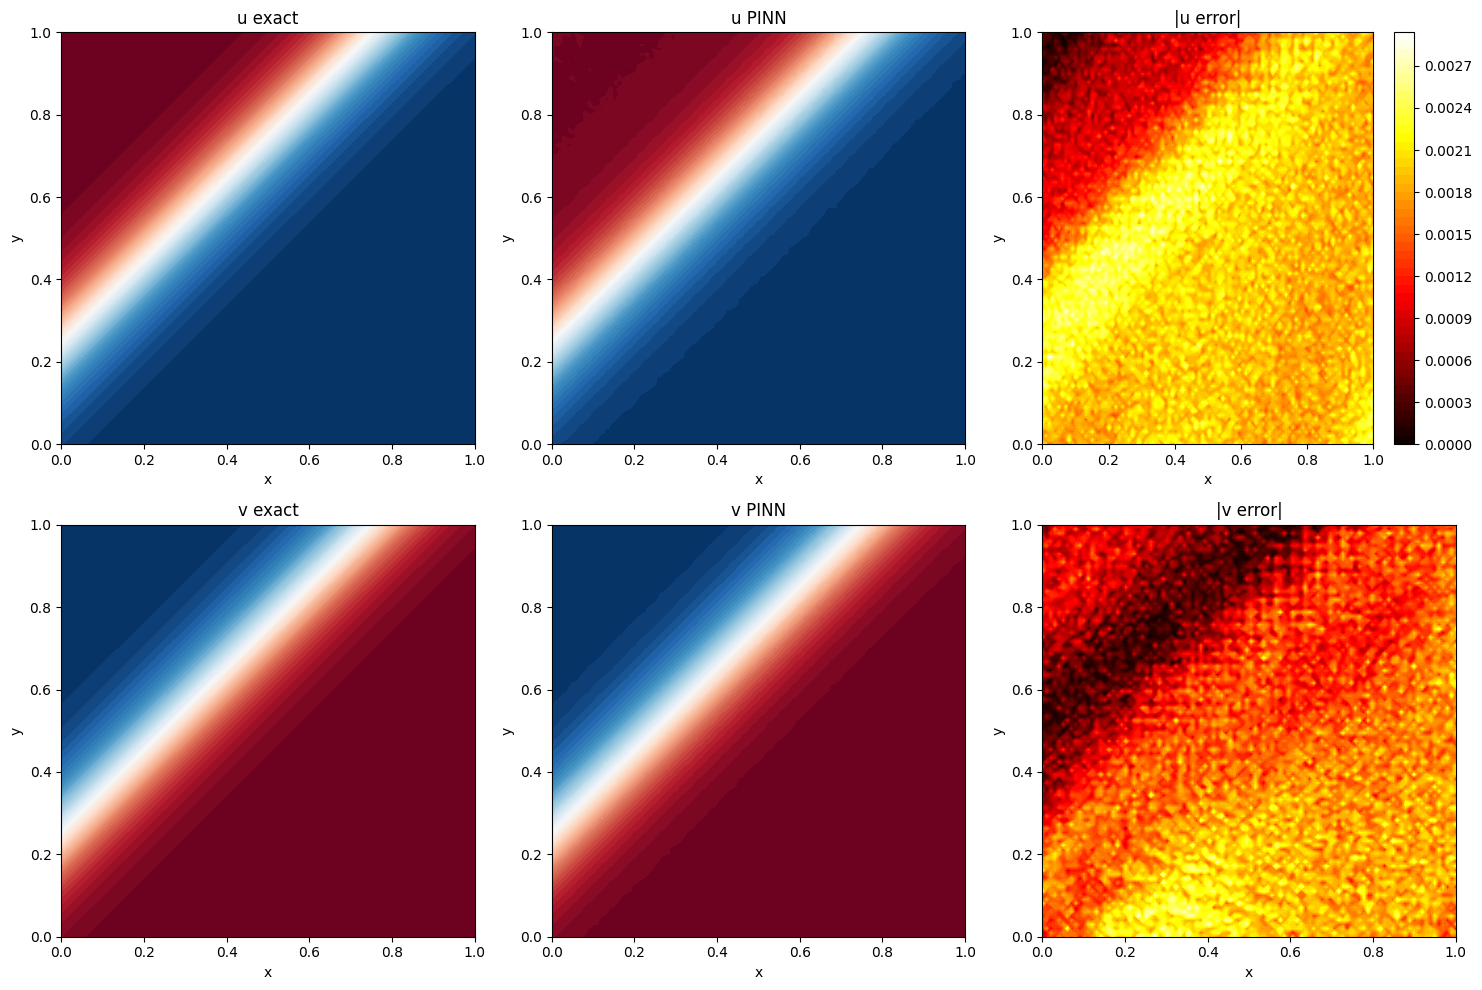

Max u error: 0.002886
Max v error: 0.001730


In [6]:
import matplotlib.pyplot as plt

# Create evaluation grid
x_plot = jnp.linspace(0, 1, 100)
y_plot = jnp.linspace(0, 1, 100)
X, Y = jnp.meshgrid(x_plot, y_plot)

# Exact solution at t=1
u_exact, v_exact = exact_solution(1.0, X, Y, nu)

# PINN prediction at t=1
T_flat = jnp.ones_like(X.ravel()) * 1.0
txy = jnp.column_stack([T_flat, X.ravel(), Y.ravel()])
uv_pred = network(params, txy)
u_pred = uv_pred[:, 0].reshape(X.shape)
v_pred = uv_pred[:, 1].reshape(X.shape)

# Plot: exact vs predicted for both components
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# u component
axes[0,0].contourf(X, Y, u_exact, levels=50, cmap='RdBu_r')
axes[0,0].set_title('u exact')
axes[0,1].contourf(X, Y, u_pred, levels=50, cmap='RdBu_r')
axes[0,1].set_title('u PINN')
axes[0,2].contourf(X, Y, jnp.abs(u_exact - u_pred), levels=50, cmap='hot')
axes[0,2].set_title('|u error|')

# v component
axes[1,0].contourf(X, Y, v_exact, levels=50, cmap='RdBu_r')
axes[1,0].set_title('v exact')
axes[1,1].contourf(X, Y, v_pred, levels=50, cmap='RdBu_r')
axes[1,1].set_title('v PINN')
axes[1,2].contourf(X, Y, jnp.abs(v_exact - v_pred), levels=50, cmap='hot')
axes[1,2].set_title('|v error|')

for ax in axes.flat:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

c = axes[0,2].contourf(X, Y, jnp.abs(u_exact - u_pred), levels=50, cmap='hot')
plt.colorbar(c, ax=axes[0,2])
plt.tight_layout()
plt.show()

print(f"Max u error: {jnp.max(jnp.abs(u_exact - u_pred)):.6f}")
print(f"Max v error: {jnp.max(jnp.abs(v_exact - v_pred)):.6f}")

## Quiver Plot

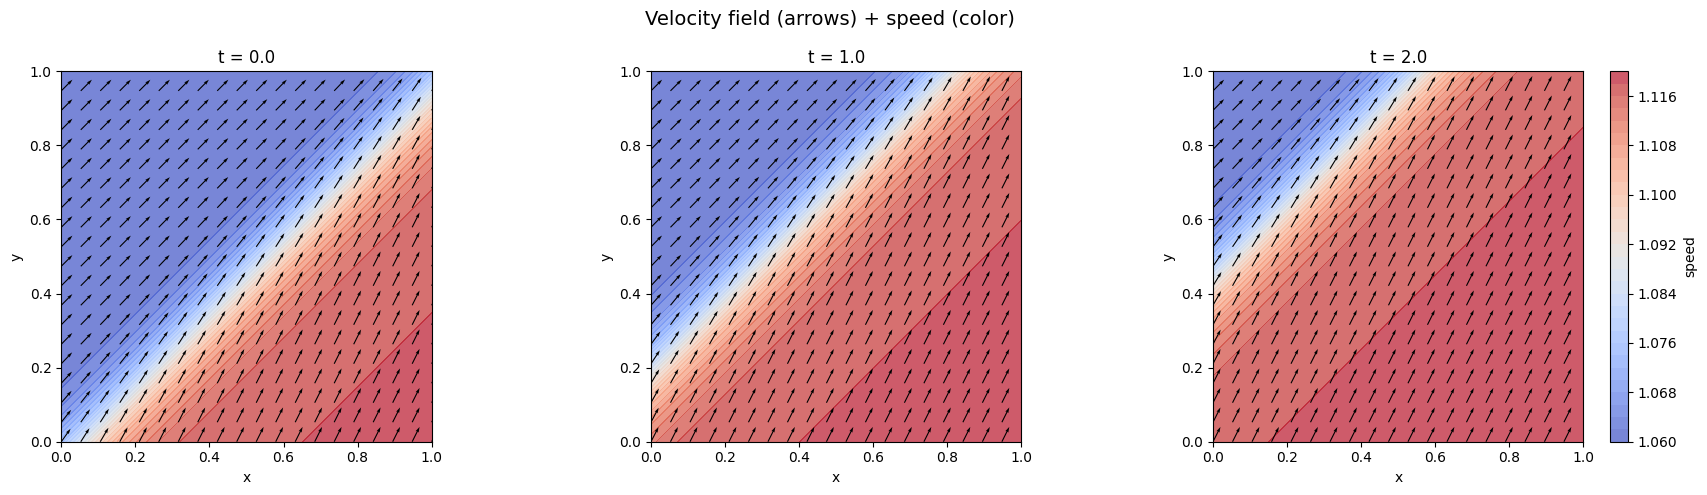

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, t_val in enumerate([0.0, 1.0, 2.0]):
    ax = axes[idx]
    
    # Coarse grid for arrows (too many arrows = unreadable)
    x_q = jnp.linspace(0, 1, 20)
    y_q = jnp.linspace(0, 1, 20)
    Xq, Yq = jnp.meshgrid(x_q, y_q)
    
    u_val, v_val = exact_solution(t_val, Xq, Yq, nu)
    
    # Color background showing speed = sqrt(u² + v²)
    speed = jnp.sqrt(u_val**2 + v_val**2)
    c = ax.contourf(Xq, Yq, speed, levels=30, cmap='coolwarm', alpha=0.7)
    
    # Arrows showing direction and magnitude
    ax.quiver(Xq, Yq, u_val, v_val, color='black', scale=25)
    
    ax.set_title(f't = {t_val}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

plt.colorbar(c, ax=axes[-1], label='speed')
plt.suptitle('Velocity field (arrows) + speed (color)', fontsize=14)
plt.tight_layout()
plt.show()

## More Heatmaps

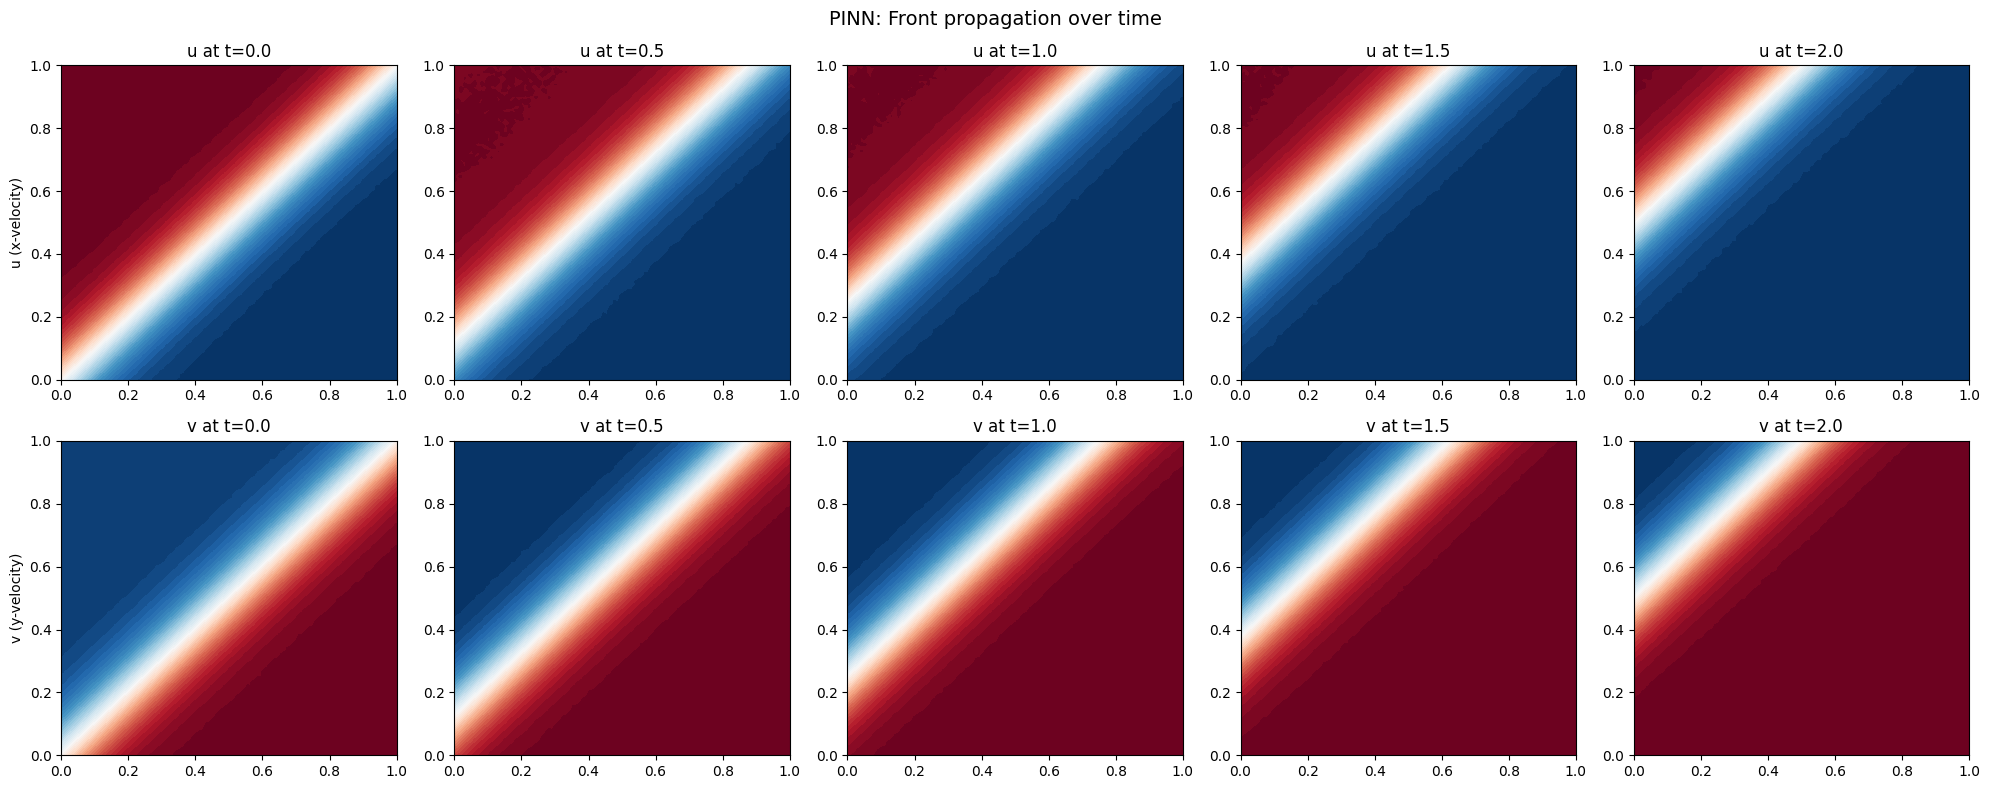

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
times = [0.0, 0.5, 1.0, 1.5, 2.0]

x_p = jnp.linspace(0, 1, 100)
y_p = jnp.linspace(0, 1, 100)
Xp, Yp = jnp.meshgrid(x_p, y_p)

for i, t_val in enumerate(times):
    # PINN prediction
    T_flat = jnp.ones_like(Xp.ravel()) * t_val
    txy = jnp.column_stack([T_flat, Xp.ravel(), Yp.ravel()])
    uv_pred = network(params, txy)
    
    axes[0, i].contourf(Xp, Yp, uv_pred[:, 0].reshape(Xp.shape), 
                         levels=50, cmap='RdBu_r')
    axes[0, i].set_title(f'u at t={t_val}')
    
    axes[1, i].contourf(Xp, Yp, uv_pred[:, 1].reshape(Xp.shape), 
                         levels=50, cmap='RdBu_r')
    axes[1, i].set_title(f'v at t={t_val}')

axes[0, 0].set_ylabel('u (x-velocity)')
axes[1, 0].set_ylabel('v (y-velocity)')
plt.suptitle('PINN: Front propagation over time', fontsize=14)
plt.tight_layout()
plt.show()

## U in 3D

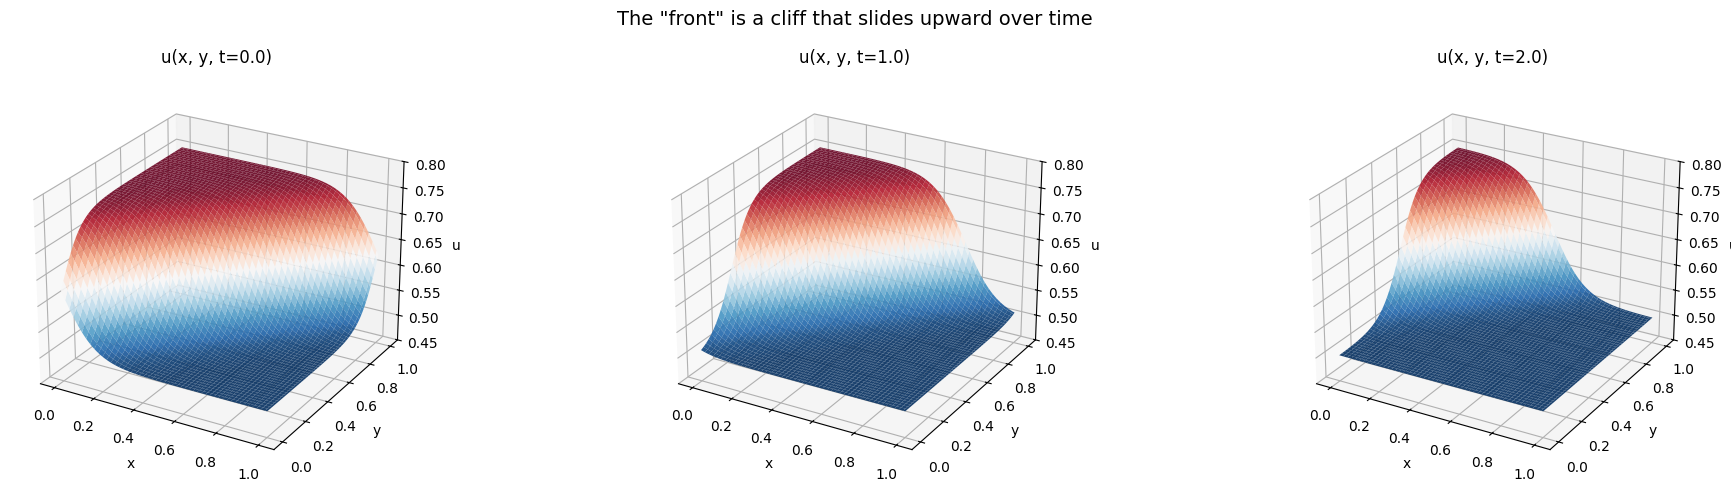

In [9]:
from mpl_toolkits.mplot3d import Axes3D

x_p = jnp.linspace(0, 1, 100)
y_p = jnp.linspace(0, 1, 100)
Xp, Yp = jnp.meshgrid(x_p, y_p)

fig = plt.figure(figsize=(20, 5))

for i, t_val in enumerate([0.0, 1.0, 2.0]):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    u_val, v_val = exact_solution(t_val, Xp, Yp, nu)
    
    ax.plot_surface(Xp, Yp, u_val, cmap='RdBu_r', alpha=0.9)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u')
    ax.set_title(f'u(x, y, t={t_val})')
    ax.set_zlim(0.45, 0.80)
    ax.view_init(elev=25, azim=-60)

plt.suptitle('The "front" is a cliff that slides upward over time', fontsize=14)
plt.tight_layout()
plt.show()

## U and V in 3D

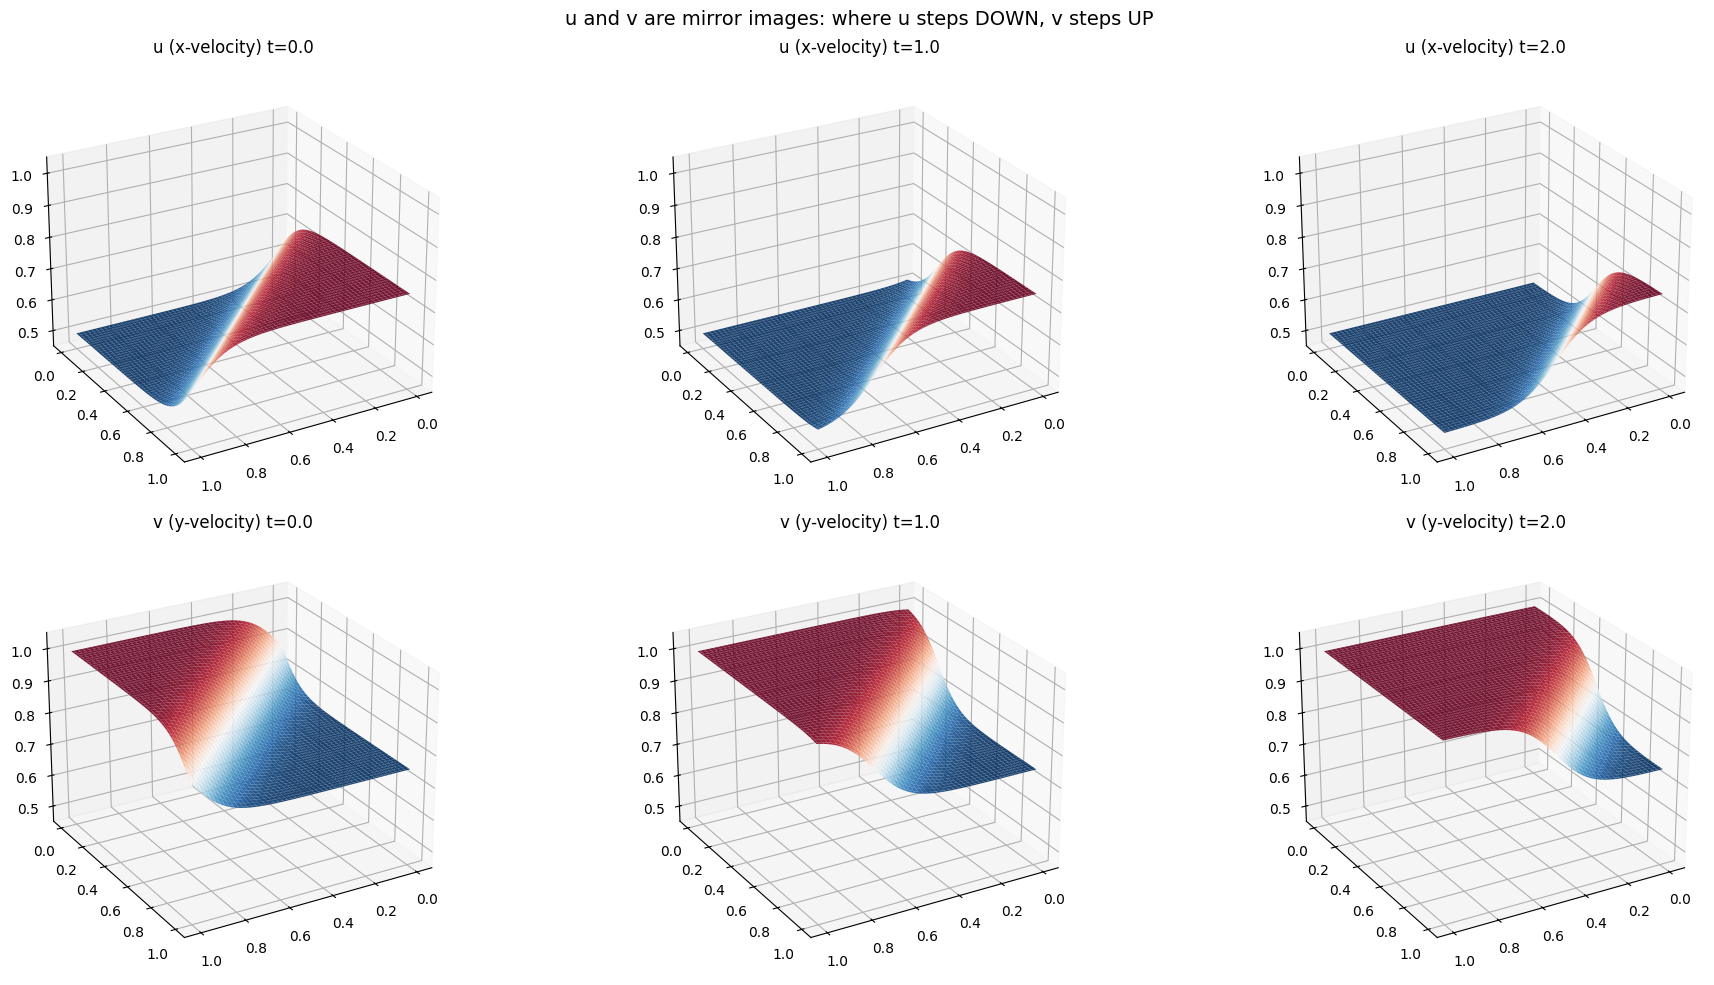

In [13]:
fig = plt.figure(figsize=(20, 10))

for i, t_val in enumerate([0.0, 1.0, 2.0]):
    u_val, v_val = exact_solution(t_val, Xp, Yp, nu)
    
    # u on top row
    ax1 = fig.add_subplot(2, 3, i+1, projection='3d')
    ax1.plot_surface(Xp, Yp, u_val, cmap='RdBu_r', alpha=0.9)
    ax1.set_title(f'u (x-velocity) t={t_val}')
    ax1.set_zlim(0.45, 1.05)
    ax1.view_init(elev=25, azim=-60)
    ax1.view_init(elev=25, azim=60)    # from the other side
    # v on bottom row
    ax2 = fig.add_subplot(2, 3, i+4, projection='3d')
    ax2.plot_surface(Xp, Yp, v_val, cmap='RdBu_r', alpha=0.9)
    ax2.set_title(f'v (y-velocity) t={t_val}')
    ax2.set_zlim(0.45, 1.05)
    ax2.view_init(elev=25, azim=60)    # from the other side

plt.suptitle('u and v are mirror images: where u steps DOWN, v steps UP', fontsize=14)
plt.tight_layout()
plt.show()

## Training Evolution GIF

Saved: u_training_evolution_t1.gif


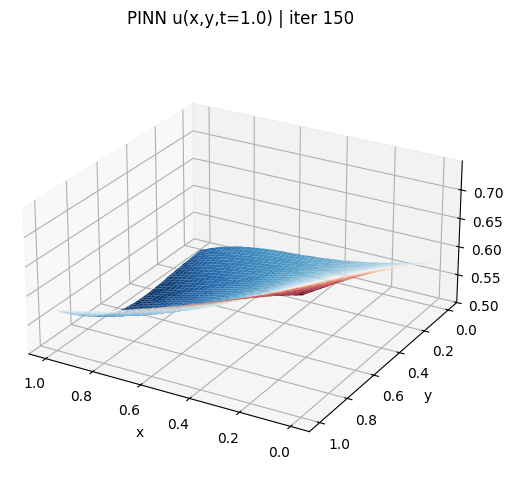

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# -------- settings --------
t_val = 1.0
fps = 20
stride = 1
gif_name = "u_training_evolution_t1.gif"

# If you already have Xp, Yp from earlier, you can delete this block.
x_p = jnp.linspace(0, 1, 100)
y_p = jnp.linspace(0, 1, 100)
Xp, Yp = jnp.meshgrid(x_p, y_p)

# Prebuild txy for fixed t (so update() only changes params)
T_flat = jnp.ones_like(Xp.ravel()) * t_val
txy_fixed = jnp.column_stack([T_flat, Xp.ravel(), Yp.ravel()])

pred_uv = jax.jit(lambda p: network(p, txy_fixed))

# Consistent z-range (important)
u_exact, _ = exact_solution(t_val, Xp, Yp, nu)
zmin = float(jnp.min(u_exact))
zmax = float(jnp.max(u_exact))

Xnp = np.array(Xp)
Ynp = np.array(Yp)

frames = list(range(0, len(snapshots), stride))
if len(frames) == 0:
    raise ValueError("No frames: snapshots is empty (len(snapshots)==0).")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("u")
ax.set_zlim(zmin, zmax)
ax.set_box_aspect((1, 1, 0.5))
ax.view_init(elev=25, azim=120)

# initial surface
uv0 = pred_uv(snapshots[frames[0]])
u0 = np.array(uv0[:, 0].reshape(Xp.shape))
surf = ax.plot_surface(Xnp, Ynp, u0, cmap="RdBu_r", linewidth=0, antialiased=True)
title = ax.set_title(f"PINN u(x,y,t={t_val}) | iter {snapshot_iterations[frames[0]]}")

def update(k):
    global surf
    # remove previous surface safely
    surf.remove()

    p = snapshots[frames[k]]
    it = snapshot_iterations[frames[k]]

    uv = pred_uv(p)
    u = np.array(uv[:, 0].reshape(Xp.shape))

    # redraw
    surf = ax.plot_surface(Xnp, Ynp, u, cmap="RdBu_r", linewidth=0, antialiased=True)
    title.set_text(f"PINN u(x,y,t={t_val}) | iter {it}")
    return (surf, title)

ani = FuncAnimation(fig, update, frames=len(frames), interval=50, blit=False)
ani.save(gif_name, writer=PillowWriter(fps=fps))
print("Saved:", gif_name)

## Wave evolution

Saved wave_evolution.gif


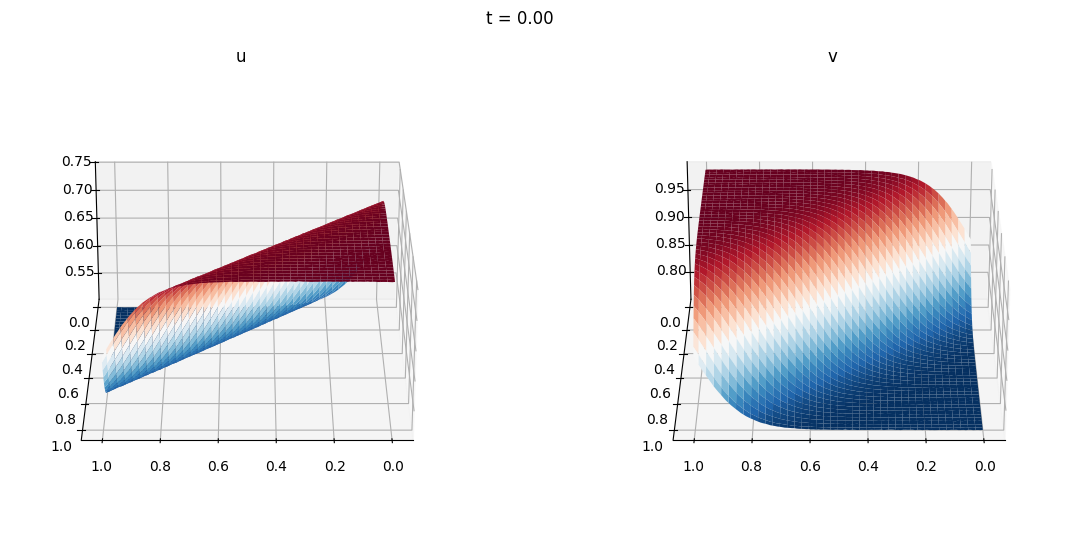

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ---- time settings ----
t_vals = np.linspace(0.0, 2.0, 60)
fps = 20

# ---- grid (use yours if already defined) ----
x_p = jnp.linspace(0, 1, 120)
y_p = jnp.linspace(0, 1, 120)
Xp, Yp = jnp.meshgrid(x_p, y_p)

Xnp = np.array(Xp)
Ynp = np.array(Yp)

# ---- prediction function ----
def predict(t):
    T = jnp.ones_like(Xp.ravel()) * t
    txy = jnp.column_stack([T, Xp.ravel(), Yp.ravel()])
    uv = network(params, txy)
    u = np.array(uv[:,0].reshape(Xp.shape))
    v = np.array(uv[:,1].reshape(Xp.shape))
    return u, v

# ---- compute fixed z limits so plot doesn't rescale ----
u_sample, v_sample = predict(1.0)
u_min, u_max = u_sample.min(), u_sample.max()
v_min, v_max = v_sample.min(), v_sample.max()

# ---- figure ----
fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(1,2,1, projection="3d")
ax2 = fig.add_subplot(1,2,2, projection="3d")

for ax in [ax1, ax2]:
    ax.set_box_aspect((1,1,0.5))
    ax.view_init(elev=25, azim=90)

ax1.set_zlim(u_min, u_max)
ax2.set_zlim(v_min, v_max)
ax1.set_title("u")
ax2.set_title("v")

# initial surface
u0, v0 = predict(t_vals[0])
surf_u = ax1.plot_surface(Xnp, Ynp, u0, cmap="RdBu_r")
surf_v = ax2.plot_surface(Xnp, Ynp, v0, cmap="RdBu_r")

def update(frame):
    global surf_u, surf_v
    
    t = t_vals[frame]

    surf_u.remove()
    surf_v.remove()

    u, v = predict(t)

    surf_u = ax1.plot_surface(Xnp, Ynp, u, cmap="RdBu_r")
    surf_v = ax2.plot_surface(Xnp, Ynp, v, cmap="RdBu_r")

    fig.suptitle(f"t = {t:.2f}")
    return surf_u, surf_v

ani = FuncAnimation(fig, update, frames=len(t_vals), interval=50)
ani.save("wave_evolution.gif", writer=PillowWriter(fps=fps))

print("Saved wave_evolution.gif")

## Moving wavefront GIF

Saved wavefront_uv.gif


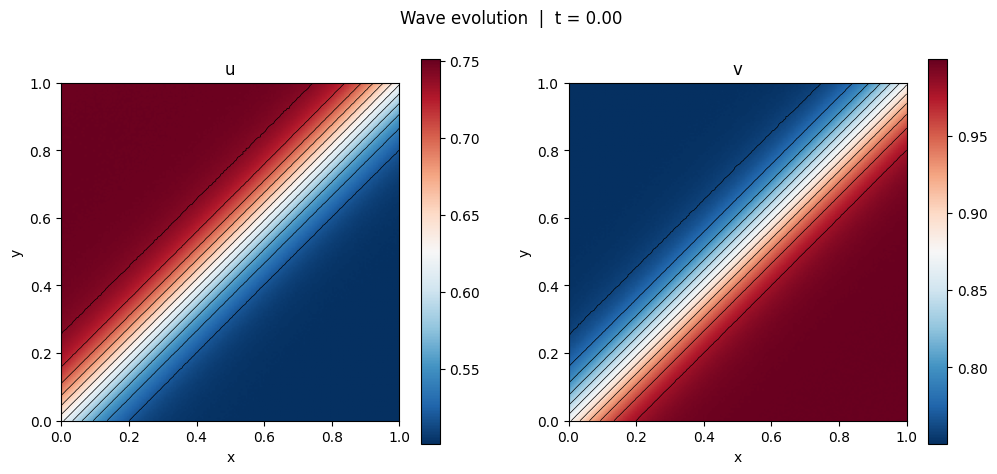

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# ---- time settings ----
t_vals = np.linspace(0.0, 2.0, 80)
fps = 20

# ---- grid (use your grid if already defined) ----
x_p = jnp.linspace(0, 1, 200)
y_p = jnp.linspace(0, 1, 200)
Xp, Yp = jnp.meshgrid(x_p, y_p)

Xnp = np.array(Xp)
Ynp = np.array(Yp)

# ---- prediction ----
def predict(t):
    T = jnp.ones_like(Xp.ravel()) * t
    txy = jnp.column_stack([T, Xp.ravel(), Yp.ravel()])
    uv = network(params, txy)
    u = np.array(uv[:, 0].reshape(Xp.shape))
    v = np.array(uv[:, 1].reshape(Xp.shape))
    return u, v

# ---- fixed color scaling (important!) ----
u_sample, v_sample = predict(1.0)
u_min, u_max = u_sample.min(), u_sample.max()
v_min, v_max = v_sample.min(), v_sample.max()

# ---- figure ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# initial frame
u0, v0 = predict(t_vals[0])

im_u = axes[0].imshow(u0, origin="lower", extent=[0, 1, 0, 1],
                      cmap="RdBu_r", vmin=u_min, vmax=u_max)
im_v = axes[1].imshow(v0, origin="lower", extent=[0, 1, 0, 1],
                      cmap="RdBu_r", vmin=v_min, vmax=v_max)

axes[0].set_title("u")
axes[1].set_title("v")
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')

plt.colorbar(im_u, ax=axes[0])
plt.colorbar(im_v, ax=axes[1])

# Keep contour handles in mutable containers so update() can replace them
state = {
    'cont_u': axes[0].contour(Xnp, Ynp, u0, colors='k', levels=15, linewidths=0.5),
    'cont_v': axes[1].contour(Xnp, Ynp, v0, colors='k', levels=15, linewidths=0.5),
}

def update(frame):
    t = t_vals[frame]
    u, v = predict(t)

    im_u.set_data(u)
    im_v.set_data(v)

    # Matplotlib-version-safe contour replacement
    state['cont_u'].remove()
    state['cont_v'].remove()

    state['cont_u'] = axes[0].contour(Xnp, Ynp, u, colors='k', levels=15, linewidths=0.5)
    state['cont_v'] = axes[1].contour(Xnp, Ynp, v, colors='k', levels=15, linewidths=0.5)

    fig.suptitle(f'Wave evolution  |  t = {t:.2f}')
    return (im_u, im_v)

ani = FuncAnimation(fig, update, frames=len(t_vals), interval=50, blit=False)
ani.save('wavefront_uv.gif', writer=PillowWriter(fps=fps))

print('Saved wavefront_uv.gif')


## loss curve

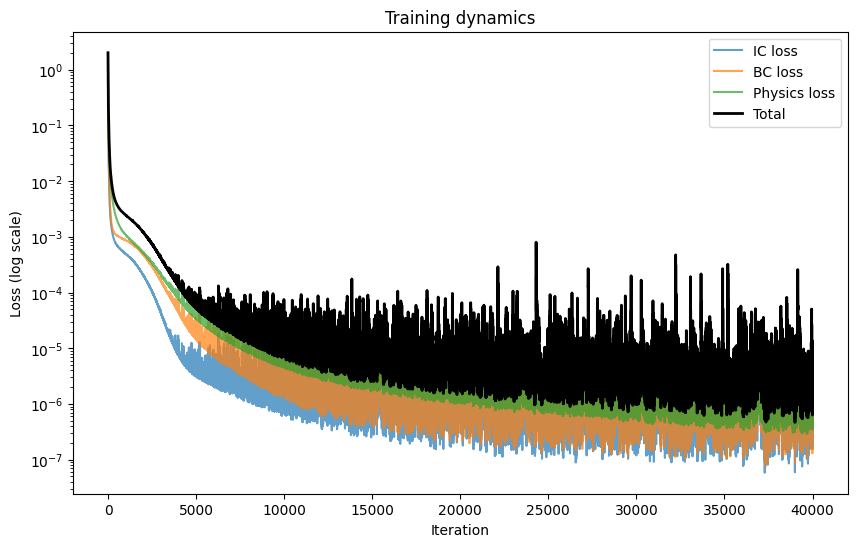

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
iters = range(len(losses))
ax.semilogy(iters, losses_ic, label='IC loss', alpha=0.7)
ax.semilogy(iters, losses_bc, label='BC loss', alpha=0.7)
ax.semilogy(iters, losses_physics, label='Physics loss', alpha=0.7)
ax.semilogy(iters, losses, label='Total', color='black', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (log scale)')
ax.legend()
ax.set_title('Training dynamics')
plt.show()

# Relative L^2 Error Over Time

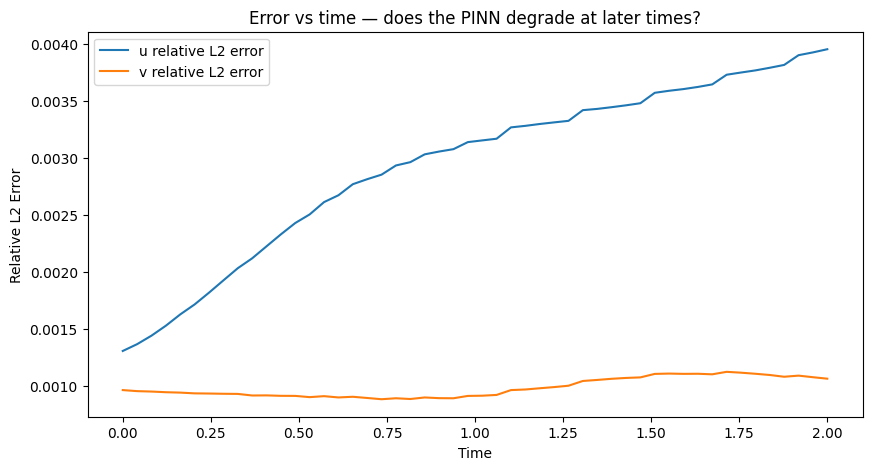

In [30]:
times = jnp.linspace(0, 2.0, 50)
errors_u = []
errors_v = []

for t_val in times:
    u_ex, v_ex = exact_solution(t_val, Xp, Yp, nu)
    
    T_flat = jnp.ones_like(Xp.ravel()) * t_val
    txy = jnp.column_stack([T_flat, Xp.ravel(), Yp.ravel()])
    uv_pred = network(params, txy)
    u_pr = uv_pred[:, 0].reshape(Xp.shape)
    v_pr = uv_pred[:, 1].reshape(Xp.shape)
    
    # Relative L2 error: ||pred - exact|| / ||exact||
    err_u = jnp.sqrt(jnp.mean((u_pr - u_ex)**2)) / jnp.sqrt(jnp.mean(u_ex**2))
    err_v = jnp.sqrt(jnp.mean((v_pr - v_ex)**2)) / jnp.sqrt(jnp.mean(v_ex**2))
    errors_u.append(err_u)
    errors_v.append(err_v)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(times, errors_u, label='u relative L2 error')
ax.plot(times, errors_v, label='v relative L2 error')
ax.set_xlabel('Time')
ax.set_ylabel('Relative L2 Error')
ax.legend()
ax.set_title('Error vs time — does the PINN degrade at later times?')
plt.show()